# Model Robustness Comparison (Radar Chart)

This notebook visualizes the quantitative robustness of EfficientNetB0, InceptionV3, and MobileNetV2 against various adversarial attacks. 

We use a **Radar Chart (Spider Chart)** to display the accuracy of each model under different attack scenarios. We load the evaluation metrics directly from the `robustness_metrics.csv` file generated by the master evaluation script. In this chart, the outer edge represents 100% accuracy (perfect robustness), while the center represents 0% accuracy (complete vulnerability).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi
import plotly.graph_objects as go

In [2]:
# Define specific colors for each model
model_colors = {
    'EfficientNetB0': '#2ca02c', # Green
    'InceptionV3': '#1f77b4', # Blue
    'MobileNetV2': '#ff7f0e' # Orange
}

In [3]:
# Load the metrics from the CSV file
try:
    df = pd.read_csv('robustness_metrics.csv')
    print("Metrics loaded successfully!")
except FileNotFoundError:
    print("Error: 'robustness_metrics.csv' not found. Please run the evaluation notebook first.")

Metrics loaded successfully!


In [4]:
# Define the categories (The attacks evaluated)
categories = ['Baseline', 'FGSM', 'PGD', 'DeepFool', 'C&W', 'T-IFGSM']
N = len(categories)

# Extract the Accuracy (%) for each model and format it for the radar chart
robustness_data = {}
for model_name in df['Model'].unique():
    model_df = df[df['Model'] == model_name]
    
    acc_list = []
    for cat in categories:
        # Extract the accuracy value for the specific attack
        val = model_df[model_df['Attack'] == cat]['Accuracy (%)'].values
        acc_list.append(val[0] if len(val) > 0 else 0.0)
        
    robustness_data[model_name] = acc_list

print("Data successfully parsed for plotting.")

Data successfully parsed for plotting.


### Generating the Radar Chart
To plot a Radar Chart in Matplotlib, we need to compute the angles for each axis in a polar plot and explicitly close the loop of the data array so the lines connect seamlessly.

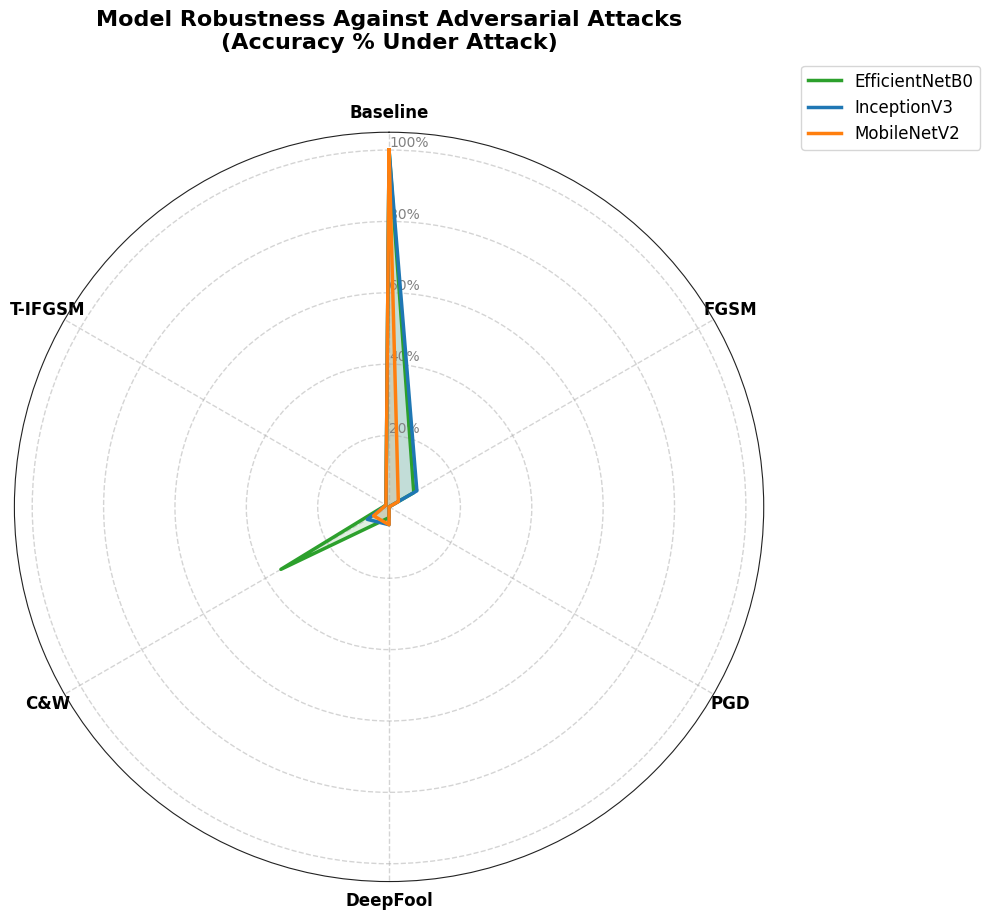

In [5]:
# Calculate the angle of each axis in the plot (divide a circle into N parts)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1] # Close the circle by appending the first angle at the end

# Initialize the spider plot
plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

# Set the first axis to be on top
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)

# Draw one axe per variable and add labels
plt.xticks(angles[:-1], categories, size=12, fontweight='bold')

# Draw ylabels (Accuracy percentages)
ax.set_rlabel_position(0)
plt.yticks([20, 40, 60, 80, 100], ["20%", "40%", "60%", "80%", "100%"], color="grey", size=10)
plt.ylim(0, 105)

# Plot data for each model
for model_name, data in robustness_data.items():
    
    # We need to append the first value to the end to close the circular graph
    values = data + data[:1]
    color = model_colors.get(model_name, '#333333')
    
    # Plot the outline
    ax.plot(angles, values, linewidth=2.5, linestyle='solid', label=model_name, color=color)
    
    # Fill the area
    ax.fill(angles, values, color=color, alpha=0.15)

# Add a professional title and legend
plt.title('Model Robustness Against Adversarial Attacks\n(Accuracy % Under Attack)', size=16, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)

# Tweak gridlines for a cleaner look
ax.grid(color='#AAAAAA', linestyle='--', linewidth=1, alpha=0.5)
ax.spines['polar'].set_color('#222222')

plt.tight_layout()
plt.show()

Interactive chart saved as 'interactive_radar_chart.html'


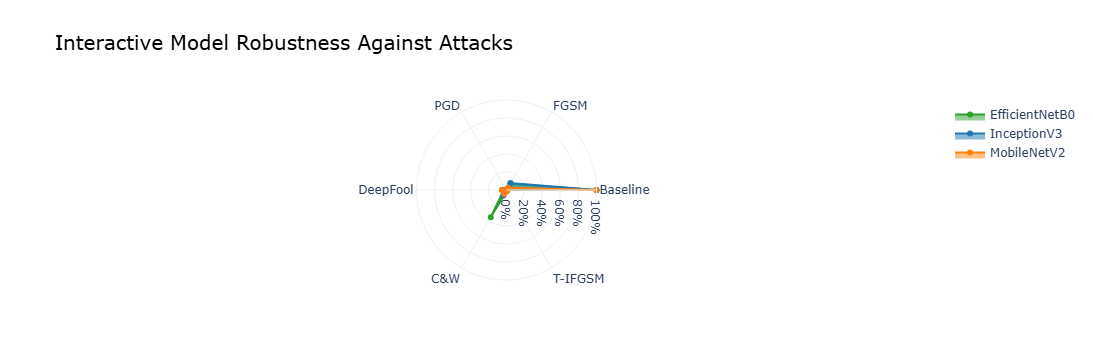

In [6]:
fig = go.Figure()

for model_name, data in robustness_data.items():
    # Plotly's Scatterpolar automatically closes the loop, so we remove the duplicate last value
    actual_data = data[:-1] if len(data) > len(categories) else data
    
    fig.add_trace(go.Scatterpolar(
        r=actual_data,
        theta=categories,
        fill='toself',
        name=model_name,
        line=dict(color=model_colors.get(model_name)),
        hoverinfo="name+r+theta"
    ))

fig.update_layout(
    title=dict(text="Interactive Model Robustness Against Attacks", font=dict(size=20, color='black')),
    polar=dict(
        radialaxis=dict(visible=True, range=[0, 100], ticksuffix="%")
    ),
    showlegend=True,
    template="plotly_white"
)

# Save as interactive HTML
html_file = "interactive_radar_chart.html"
fig.write_html(html_file)
print(f"Interactive chart saved as '{html_file}'")

# Display in notebook
fig.show()